<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 4</b></center>    
<pre>    

## Simple Linear Regression

## Step 1. Import the necessary libraries

In [12]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Step 2. Import the dataset

In [4]:
df=pd.read_csv('50_Startups.csv')

In [5]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


## Step 3 . Check the State Column

In [6]:
df.State.value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## Step 4 . Splitting dataset in to input and output

In [17]:
x=df.iloc[::, :4:]
y=df.iloc[::, 4::]



## Step 5 . Convert state Column into Numeric Column

## Step 5.1 .  Perform Transformation

In [18]:
x1=pd.get_dummies(x, columns=['State'], drop_first=True)

In [19]:
x1

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


## Step 6 . Dummy variable trap

In [ ]:
# Already Performed using | drop_first =True


## Step 7 Splitting dataset in to Train and Test

In [98]:
x_train, x_test, y_train, y_test = train_test_split(x1, y, test_size=0.2, random_state=1)

## Step 8  Import LinearRegression model from linear_model family 

In [99]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

## Step 9  Fit the data

In [100]:
model.fit(x_train, y_train)

LinearRegression()

## Step 10  Predict the data

In [101]:
y_predict=model.predict(x_test)

## Step 11  Display Result

In [102]:
# y_test and y_predict

y_test

,Profit
27,105008.31
35,96479.51
40,78239.91
38,81229.06
2,191050.39
3,182901.99
48,35673.41
29,101004.64
46,49490.75
31,97483.56


In [103]:
y_predict

array([[114664.4171587 ],
       [ 90593.15531618],
       [ 75692.84151576],
       [ 70221.88679649],
       [179790.2551487 ],
       [171576.9201852 ],
       [ 49753.58752024],
       [102276.65888937],
       [ 58649.37795765],
       [ 98272.02561132]])

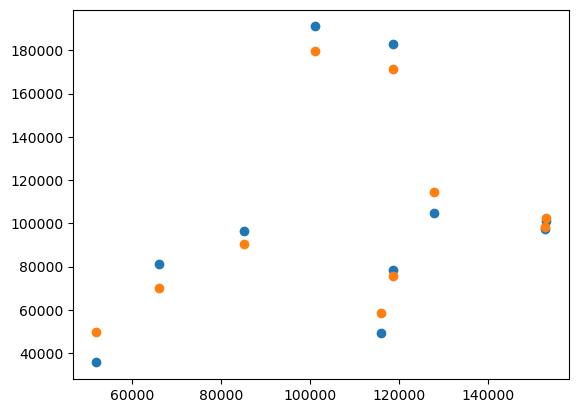

In [104]:
import matplotlib.pyplot as plt

plt.scatter(x_test['Administration'], y_test)
plt.scatter(x_test['Administration'], y_predict)


## RSS

In [105]:
import numpy as np

In [106]:
np.sum((y_test.values - y_predict) ** 2)

794954415.0424445

In [107]:
len(y_test)

10

In [108]:
from sklearn.metrics import mean_squared_error


In [109]:
mean_squared_error(y_test.values, y_predict)

79495441.50424445

## R Square

In [110]:
from sklearn.metrics import r2_score

In [111]:
r2_score(y_test, y_predict)

0.9649618042059875

## Now use Polynomial Regression on Position_Salaries dataset

In [146]:
from sklearn.preprocessing import PolynomialFeatures

In [137]:
df=pd.read_csv('position_Salaries.csv')

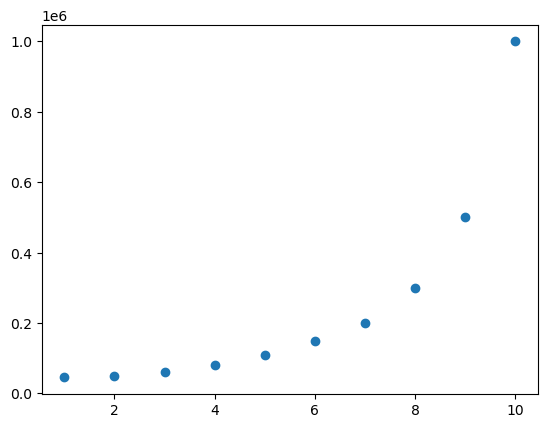

In [138]:
plt.scatter(df.Level, df.Salary)

In [139]:
x=df.iloc[::, 1:2]
y=df['Salary']
x

,Level
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [140]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=7)
x_train

,Level
2,3
1,2
9,10
7,8
3,4
6,7
4,5


In [141]:
poly=PolynomialFeatures(degree=2)

In [154]:
x1=poly.fit_transform(x)
y_train

2      60000
1      50000
9    1000000
7     300000
3      80000
6     200000
4     110000
Name: Salary, dtype: int64

In [152]:
model1=LinearRegression()


In [155]:
model1.fit(x1,y_train.values)

ValueError: Found input variables with inconsistent numbers of samples: [10, 7]

In [ ]:
y_poly_predict = model1.predict(poly.fit_transform(x_test))

AttributeError: 'PolynomialFeatures' object has no attribute 'predict'